In [ ]:

#Grid search would of take about 97hours to complete so I used random search

# Train an XGBoost model
model = xgb.XGBRegressor(objective ='reg:squarederror', n_estimators=100, learning_rate=0.05)
# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           cv=3, n_jobs=-1, scoring='neg_mean_squared_error', verbose=2)

# Perform the grid search
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)


NameError: name 'xgb' is not defined

In [ ]:
!pip install shap
!pip install lime
!pip install xgboost
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier  # You can choose a different model here
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import shap
import lime
import lime.lime_tabular
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283835 sha256=9ad41e240487ea5d38918b6bd86612d8dab026671320195e64c91df7094a494e
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 MB 3.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
# Load the data
file_path = "/content/drive/MyDrive/18wksRTT - Monthly EXTRACTS - Jan17 revised.csv"
df = pd.read_csv(file_path)

df1 = df.sample(frac=0.1, random_state=42)

In [ ]:
df1

,Year,Period Name,Provider Parent Org Code,Provider Parent Name,Provider Org Code,Provider Org Name,Commissioner Parent Org Code,Commissioner Parent Name,Commissioner Org Code,Commissioner Org Name,...,Gt 47 To 48 Weeks SUM 1,Gt 48 To 49 Weeks SUM 1,Gt 49 To 50 Weeks SUM 1,Gt 50 To 51 Weeks SUM 1,Gt 51 To 52 Weeks SUM 1,Gt 52 Weeks SUM 1,Total,Patients with unknown clock start date,Total All,Status
108097,2016-17,JANUARY,Q77,NHS ENGLAND MIDLANDS AND EAST (WEST MIDLANDS),NT412,BMI - THE DROITWICH SPA HOSPITAL,Q77,NHS ENGLAND MIDLANDS AND EAST (WEST MIDLANDS),05C,NHS DUDLEY CCG,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,3,PUBLIC
151674,2016-17,JANUARY,Q80,NHS ENGLAND SOUTH (SOUTH WEST),RBA,TAUNTON AND SOMERSET NHS FOUNDATION TRUST,Q79,NHS ENGLAND MIDLANDS AND EAST (EAST),06H,NHS CAMBRIDGESHIRE AND PETERBOROUGH CCG,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1,PUBLIC
135428,2016-17,JANUARY,Q79,NHS ENGLAND MIDLANDS AND EAST (EAST),NVC06,FITZWILLIAM HOSPITAL,Q72,NHS ENGLAND NORTH (YORKSHIRE AND HUMBER),03C,NHS LEEDS WEST CCG,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1,PUBLIC
66614,2016-17,JANUARY,Q72,NHS ENGLAND NORTH (YORKSHIRE AND HUMBER),RFF,BARNSLEY HOSPITAL NHS FOUNDATION TRUST,Q72,NHS ENGLAND NORTH (YORKSHIRE AND HUMBER),03A,NHS GREATER HUDDERSFIELD CCG,...,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,19,PUBLIC
113914,2016-17,JANUARY,Q77,NHS ENGLAND MIDLANDS AND EAST (WEST MIDLANDS),RL4,THE ROYAL WOLVERHAMPTON NHS TRUST,Q77,NHS ENGLAND MIDLANDS AND EAST (WEST MIDLANDS),05C,NHS DUDLEY CCG,...,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4,PUBLIC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154459,2016-17,JANUARY,Q80,NHS ENGLAND SOUTH (SOUTH WEST),RVJ,NORTH BRISTOL NHS TRUST,Q80,NHS ENGLAND SOUTH (SOUTH WEST),11H,NHS BRISTOL CCG,...,0.0,0.0,0.0,0.0,0.0,0.0,89.0,0.0,89,PUBLIC
118864,2016-17,JANUARY,Q77,NHS ENGLAND MIDLANDS AND EAST (WEST MIDLANDS),RRJ,THE ROYAL ORTHOPAEDIC HOSPITAL NHS FOUNDATION ...,Q72,NHS ENGLAND NORTH (YORKSHIRE AND HUMBER),03C,NHS LEEDS WEST CCG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,PUBLIC
140884,2016-17,JANUARY,Q79,NHS ENGLAND MIDLANDS AND EAST (EAST),RGP,JAMES PAGET UNIVERSITY HOSPITALS NHS FOUNDATIO...,Q79,NHS ENGLAND MIDLANDS AND EAST (EAST),06V,NHS NORTH NORFOLK CCG,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,23,PUBLIC
171964,2016-17,JANUARY,Q82,NHS ENGLAND SOUTH (SOUTH CENTRAL),AAH,TETBURY HOSPITAL TRUST LTD,Q82,NHS ENGLAND SOUTH (SOUTH CENTRAL),11M,NHS GLOUCESTERSHIRE CCG,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,5,PUBLIC


In [ ]:
df1.dtypes

Year                                       object
Period Name                                object
Provider Parent Org Code                   object
Provider Parent Name                       object
Provider Org Code                          object
                                           ...   
Gt 52 Weeks SUM 1                         float64
Total                                     float64
Patients with unknown clock start date    float64
Total All                                   int64
Status                                     object
Length: 71, dtype: object

In [ ]:
df1.describe()

,Gt 00 To 01 Weeks SUM 1,Gt 01 To 02 Weeks SUM 1,Gt 02 To 03 Weeks SUM 1,Gt 03 To 04 Weeks SUM 1,Gt 04 To 05 Weeks SUM 1,Gt 05 To 06 Weeks SUM 1,Gt 06 To 07 Weeks SUM 1,Gt 07 To 08 Weeks SUM 1,Gt 08 To 09 Weeks SUM 1,Gt 09 To 10 Weeks SUM 1,...,Gt 46 To 47 Weeks SUM 1,Gt 47 To 48 Weeks SUM 1,Gt 48 To 49 Weeks SUM 1,Gt 49 To 50 Weeks SUM 1,Gt 50 To 51 Weeks SUM 1,Gt 51 To 52 Weeks SUM 1,Gt 52 Weeks SUM 1,Total,Patients with unknown clock start date,Total All
count,15499.000000,15499.000000,15499.000000,15499.000000,15499.000000,15499.000000,15499.000000,15499.000000,15499.000000,15499.000000,...,15499.000000,15499.000000,15499.000000,15499.000000,15499.000000,15499.000000,15499.000000,6031.000000,6031.000000,20103.000000
mean,8.018840,6.174979,5.264727,4.768695,2.940770,3.453707,4.184722,4.055229,3.800697,3.557584,...,0.030002,0.030518,0.020324,0.015614,0.013033,0.011807,0.064520,44.624606,0.014591,73.149281
std,62.017122,45.939732,40.572178,36.090407,20.299137,24.768078,30.513604,28.834218,27.929651,26.344614,...,0.355718,0.371122,0.254346,0.186702,0.166059,0.159210,1.396849,254.343167,0.285851,513.275910
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,14.000000
max,2125.000000,1618.000000,1698.000000,1555.000000,743.000000,930.000000,1375.000000,1262.000000,1381.000000,1443.000000,...,14.000000,17.000000,12.000000,7.000000,7.000000,6.000000,122.000000,7288.000000,14.000000,22554.000000


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20103 entries, 108097 to 152148
Data columns (total 71 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Year                                    20103 non-null  object 
 1   Period Name                             20103 non-null  object 
 2   Provider Parent Org Code                20103 non-null  object 
 3   Provider Parent Name                    20103 non-null  object 
 4   Provider Org Code                       20103 non-null  object 
 5   Provider Org Name                       20103 non-null  object 
 6   Commissioner Parent Org Code            20103 non-null  object 
 7   Commissioner Parent Name                20103 non-null  object 
 8   Commissioner Org Code                   20103 non-null  object 
 9   Commissioner Org Name                   20103 non-null  object 
 10  RTT Part Name                           20103 non-null  o

In [ ]:
label_encoder = LabelEncoder()

for col in df1.columns:
    df1[col] = label_encoder.fit_transform(df1[col])

In [ ]:
df1.dtypes

Year                                      int64
Period Name                               int64
Provider Parent Org Code                  int64
Provider Parent Name                      int64
Provider Org Code                         int64
                                          ...  
Gt 52 Weeks SUM 1                         int64
Total                                     int64
Patients with unknown clock start date    int64
Total All                                 int64
Status                                    int64
Length: 71, dtype: object

In [ ]:
# Define the categorical features
categorical_features = [
    'Year', 'Period Name', 'Provider Parent Org Code', 'Provider Parent Name',
    'Provider Org Code', 'Provider Org Name', 'Commissioner Parent Org Code', 'Commissioner Parent Name',
    'Commissioner Org Code', 'Commissioner Org Name', 'RTT Part Name', 'RTT Part Description',
    'Treatment Function Code', 'Treatment Function Name'
]
target_columns =  ['Gt 00 To 01 Weeks SUM 1', 'Gt 01 To 02 Weeks SUM 1', 'Gt 02 To 03 Weeks SUM 1',
           'Gt 03 To 04 Weeks SUM 1', 'Gt 04 To 05 Weeks SUM 1', 'Gt 05 To 06 Weeks SUM 1',
           'Gt 06 To 07 Weeks SUM 1', 'Gt 07 To 08 Weeks SUM 1', 'Gt 08 To 09 Weeks SUM 1',
           'Gt 09 To 10 Weeks SUM 1', 'Gt 10 To 11 Weeks SUM 1', 'Gt 11 To 12 Weeks SUM 1',
           'Gt 12 To 13 Weeks SUM 1', 'Gt 13 To 14 Weeks SUM 1', 'Gt 14 To 15 Weeks SUM 1',
           'Gt 15 To 16 Weeks SUM 1', 'Gt 16 To 17 Weeks SUM 1', 'Gt 17 To 18 Weeks SUM 1',
           'Gt 18 To 19 Weeks SUM 1', 'Gt 19 To 20 Weeks SUM 1', 'Gt 20 To 21 Weeks SUM 1',
           'Gt 21 To 22 Weeks SUM 1', 'Gt 22 To 23 Weeks SUM 1', 'Gt 23 To 24 Weeks SUM 1',
           'Gt 24 To 25 Weeks SUM 1', 'Gt 25 To 26 Weeks SUM 1', 'Gt 26 To 27 Weeks SUM 1',
           'Gt 27 To 28 Weeks SUM 1', 'Gt 28 To 29 Weeks SUM 1', 'Gt 29 To 30 Weeks SUM 1',
           'Gt 30 To 31 Weeks SUM 1', 'Gt 31 To 32 Weeks SUM 1', 'Gt 32 To 33 Weeks SUM 1',
           'Gt 33 To 34 Weeks SUM 1', 'Gt 34 To 35 Weeks SUM 1', 'Gt 35 To 36 Weeks SUM 1',
           'Gt 36 To 37 Weeks SUM 1', 'Gt 37 To 38 Weeks SUM 1', 'Gt 38 To 39 Weeks SUM 1',
           'Gt 39 To 40 Weeks SUM 1', 'Gt 40 To 41 Weeks SUM 1', 'Gt 41 To 42 Weeks SUM 1',
           'Gt 42 To 43 Weeks SUM 1', 'Gt 43 To 44 Weeks SUM 1', 'Gt 44 To 45 Weeks SUM 1',
           'Gt 45 To 46 Weeks SUM 1', 'Gt 46 To 47 Weeks SUM 1', 'Gt 47 To 48 Weeks SUM 1',
           'Gt 48 To 49 Weeks SUM 1', 'Gt 49 To 50 Weeks SUM 1', 'Gt 50 To 51 Weeks SUM 1',
           'Gt 51 To 52 Weeks SUM 1', 'Gt 52 Weeks SUM 1']

In [ ]:
df1

,Year,Period Name,Provider Parent Org Code,Provider Parent Name,Provider Org Code,Provider Org Name,Commissioner Parent Org Code,Commissioner Parent Name,Commissioner Org Code,Commissioner Org Name,...,Gt 47 To 48 Weeks SUM 1,Gt 48 To 49 Weeks SUM 1,Gt 49 To 50 Weeks SUM 1,Gt 50 To 51 Weeks SUM 1,Gt 51 To 52 Weeks SUM 1,Gt 52 Weeks SUM 1,Total,Patients with unknown clock start date,Total All,Status
108097,0,0,6,5,96,39,6,5,84,45,...,0,0,0,0,0,0,391,8,2,0
151674,0,0,9,13,215,327,8,3,103,25,...,0,0,0,0,0,0,391,8,0,0
135428,0,0,8,3,157,128,2,10,49,95,...,0,0,0,0,0,0,391,8,0,0
66614,0,0,2,10,248,13,2,10,48,63,...,0,0,0,0,0,0,19,0,18,0
113914,0,0,6,5,279,346,6,5,84,45,...,0,0,0,0,0,0,4,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154459,0,0,9,13,333,186,9,13,185,21,...,0,0,0,0,0,0,89,0,88,0
118864,0,0,6,5,317,345,2,10,49,95,...,14,10,8,8,6,25,391,8,0,0
140884,0,0,8,3,253,155,8,3,111,122,...,0,0,0,0,0,0,391,8,22,0
171964,0,0,11,11,0,329,11,11,187,61,...,0,0,0,0,0,0,5,0,4,0


In [ ]:
#3.Define features and target variable(s)
features = df1.columns.drop(['Year', 'Period Name', 'Provider Parent Name', 'Provider Org Name', 'Commissioner Parent Org Code', 'Commissioner Org Name','RTT Part Description','Treatment Function Name','Total','Status', 'Gt 00 To 01 Weeks SUM 1', 'Gt 01 To 02 Weeks SUM 1', 'Gt 02 To 03 Weeks SUM 1',
           'Gt 03 To 04 Weeks SUM 1', 'Gt 04 To 05 Weeks SUM 1', 'Gt 05 To 06 Weeks SUM 1',
           'Gt 06 To 07 Weeks SUM 1', 'Gt 07 To 08 Weeks SUM 1', 'Gt 08 To 09 Weeks SUM 1',
           'Gt 09 To 10 Weeks SUM 1', 'Gt 10 To 11 Weeks SUM 1', 'Gt 11 To 12 Weeks SUM 1',
           'Gt 12 To 13 Weeks SUM 1', 'Gt 13 To 14 Weeks SUM 1', 'Gt 14 To 15 Weeks SUM 1',
           'Gt 15 To 16 Weeks SUM 1', 'Gt 16 To 17 Weeks SUM 1', 'Gt 17 To 18 Weeks SUM 1',
           'Gt 18 To 19 Weeks SUM 1', 'Gt 19 To 20 Weeks SUM 1', 'Gt 20 To 21 Weeks SUM 1',
           'Gt 21 To 22 Weeks SUM 1', 'Gt 22 To 23 Weeks SUM 1', 'Gt 23 To 24 Weeks SUM 1',
           'Gt 24 To 25 Weeks SUM 1', 'Gt 25 To 26 Weeks SUM 1', 'Gt 26 To 27 Weeks SUM 1',
           'Gt 27 To 28 Weeks SUM 1', 'Gt 28 To 29 Weeks SUM 1', 'Gt 29 To 30 Weeks SUM 1',
           'Gt 30 To 31 Weeks SUM 1', 'Gt 31 To 32 Weeks SUM 1', 'Gt 32 To 33 Weeks SUM 1',
           'Gt 33 To 34 Weeks SUM 1', 'Gt 34 To 35 Weeks SUM 1', 'Gt 35 To 36 Weeks SUM 1',
           'Gt 36 To 37 Weeks SUM 1', 'Gt 37 To 38 Weeks SUM 1', 'Gt 38 To 39 Weeks SUM 1',
           'Gt 39 To 40 Weeks SUM 1', 'Gt 40 To 41 Weeks SUM 1', 'Gt 41 To 42 Weeks SUM 1',
           'Gt 42 To 43 Weeks SUM 1', 'Gt 43 To 44 Weeks SUM 1', 'Gt 44 To 45 Weeks SUM 1',
           'Gt 45 To 46 Weeks SUM 1', 'Gt 46 To 47 Weeks SUM 1', 'Gt 47 To 48 Weeks SUM 1',
           'Gt 48 To 49 Weeks SUM 1', 'Gt 49 To 50 Weeks SUM 1', 'Gt 50 To 51 Weeks SUM 1',
           'Gt 51 To 52 Weeks SUM 1', 'Gt 52 Weeks SUM 1'	])  # You might want to exclude 'Year' if it's not directly predictive
print(features)

Index(['Provider Parent Org Code', 'Provider Org Code',
       'Commissioner Parent Name', 'Commissioner Org Code', 'RTT Part Name',
       'Treatment Function Code', 'Patients with unknown clock start date',
       'Total All'],
      dtype='object')


In [ ]:
gc.collect()

122

In [ ]:
df_sample = df1.sample(frac=0.1, random_state=42)
X_sample = df_sample[features]
y_sample = df_sample[target_columns]


In [ ]:
# Split the sampled data into training and testing sets
X_train_sample, X_test_sample, y_train_sample, y_test_sample = train_test_split(X_sample, y_sample, test_size=0.1, random_state=42)

In [ ]:
# Get feature names BEFORE scaling
feature_names = X_train_sample.columns.tolist()

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sample)
X_test_scaled = scaler.transform(X_test_sample)


In [ ]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}


In [ ]:
print(len(feature_names))

8


In [ ]:
print(X_train_scaled.shape)

(1809, 8)


In [ ]:
# Create an XGBoost regressor
model = xgb.XGBRegressor(objective='reg:squarederror')

# Use RandomizedSearchCV (for faster exploration)
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,  # Number of parameter settings to sample
    cv=3,       # Number of cross-validation folds
    n_jobs=1,   # Single-threaded execution
    scoring='neg_mean_squared_error',  # Scoring metric
    verbose=2,  # Verbosity level
    random_state=42  # Seed for reproducibility
)

# Perform the randomized search
random_search.fit(X_train_scaled, y_train_sample)

# Get the best parameters
best_params = random_search.best_params_
print("Best parameters found: ", best_params)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=1.5, subsample=0.9; total time=  11.4s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=1.5, subsample=0.9; total time=   3.9s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=1.5, subsample=0.9; total time=   7.8s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.05, max_depth=3, n_estimators=200, reg_alpha=0.01, reg_lambda=2, subsample=0.9; total time=   2.8s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.05, max_depth=3, n_estimators=200, reg_alpha=0.01, reg_lambda=2, subsample=0.9; total time=   2.7s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.05, max_depth=3, n_estimators=200, reg_alpha=0.01, reg_lambda=2, subsample=0.9; total time= 

In [ ]:
# Train the XGBoost model with the best parameters
best_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_params.get('n_estimators', 200),
    learning_rate=best_params.get('learning_rate', 0.05),
    max_depth=best_params.get('max_depth', 3),
    subsample=best_params.get('subsample', 0.9),
    colsample_bytree=best_params.get('colsample_bytree', 0.9),
    gamma=best_params.get('gamma', 0),
    reg_alpha=best_params.get('reg_alpha', 0.01),
    reg_lambda=best_params.get('reg_lambda', 1.5)
)


In [ ]:
best_model.fit(X_train_scaled, y_train_sample)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
from sklearn.metrics import mean_squared_error
# Predict and evaluate the model
# Make predictions
train_predictions = best_model.predict(X_train_scaled)
test_predictions = best_model.predict(X_test_scaled)

# Calculate and print the mean squared error
train_mse = mean_squared_error(y_train_sample, train_predictions)
test_mse = mean_squared_error(y_test_sample, test_predictions)
print(f"Train Mean Squared Error: {train_mse}")
print(f"Test Mean Squared Error: {test_mse}")

# Display the first few predictions for the test set
print("First few predictions on the test set:")
print(test_predictions[:5])

Train Mean Squared Error: 0.9474071499344313
Test Mean Squared Error: 8.110904490507481
First few predictions on the test set:
[[ 9.94213390e+00  8.20014763e+00  4.61765289e+00  4.61010647e+00
   4.04980040e+00  3.92992783e+00  5.16348219e+00  4.16430473e+00
   3.66372943e+00  3.28117824e+00  2.50057554e+00  1.85546267e+00
   2.18512249e+00  2.07534719e+00  1.72205412e+00  1.85295355e+00
   1.95051074e+00  1.73188341e+00  6.84611380e-01  7.82519460e-01
   7.45568693e-01  6.14633620e-01  7.93850899e-01  6.86608434e-01
   4.96334881e-01  6.41346037e-01  2.88868308e-01  5.64513445e-01
   2.75705695e-01  1.57407239e-01  2.40814164e-01  1.61486223e-01
   1.00875974e-01  8.09545666e-02  8.87920856e-02  2.11389214e-01
   3.17751877e-02  1.14847813e-02  6.38050213e-02  7.85099715e-02
   1.32947057e-01  6.37927186e-03  1.04310382e-02  6.95378706e-02
   1.67341577e-03 -5.61611075e-03  4.48006764e-02  1.08452942e-02
   2.36068247e-03 -2.01145443e-03 -1.75305433e-03  3.35342265e-05
   6.30648509e-

100%|===================| 10648/10653 [21:34<00:00]       

Number of features: 8
Shape of X_test_scaled: (201, 8)
Shape of shap_values: (201, 8, 53)


IndexError: index 8 is out of bounds for axis 1 with size 8

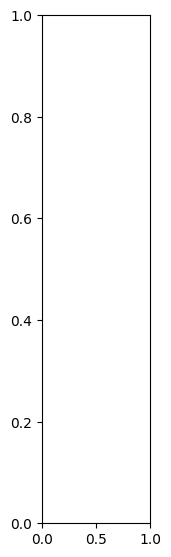

In [ ]:
# Step 5: Train the XGBoost model with the best parameters
best_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    gamma=best_params['gamma'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda']
)

best_model.fit(X_train_scaled, y_train_sample)

# Initialize the SHAP explainer with the trained model
explainer = shap.Explainer(best_model, X_train_scaled)

# Calculate SHAP values for the test set
shap_values = explainer(X_test_scaled)

# Get feature names
feature_names = features  # Assuming 'features' is defined somewhere earlier in your code

# Debugging information
print(f"Number of features: {len(features)}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of shap_values: {shap_values.shape}")

# Ensure the number of features matches
assert X_test_scaled.shape[1] == len(feature_names), "Mismatch between number of features and feature names"
assert shap_values.shape[1] == X_test_scaled.shape[1], "Mismatch between SHAP values and test data features"

# Create the summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names)

# Plot feature importances
xgb.plot_importance(best_model)
plt.show()

100%|===================| 10647/10653 [21:19<00:00]       

IndexError: index 8 is out of bounds for axis 1 with size 8

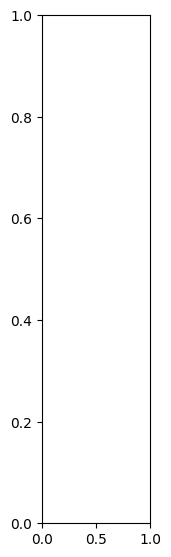

In [ ]:
# Initialize the SHAP explainer with the trained model
explainer = shap.Explainer(best_model, X_train_scaled)

# Calculate SHAP values for the test set
shap_values = explainer(X_test_scaled)

# Get feature names
feature_names = features  # Assuming 'features' is defined somewhere earlier in your code

# Create the summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names)

In [ ]:
# Initialize the SHAP explainer with the trained model
explainer = shap.Explainer(best_model, X_train_scaled)

# Calculate SHAP values for the test set
shap_values = explainer(X_test_scaled)

# Get feature names from the training set (assuming they are the same for train and test)
feature_names = features

# Plot SHAP summary plot for each target variable
for i, target in enumerate(target_columns):
    print(f"Creating SHAP summary plot for target: {target}")
    shap.summary_plot(shap_values[..., i], X_test_scaled, feature_names=features, show=False)
    plt.title(f"SHAP Summary Plot for Target: {target}")
    plt.show()

# Plot feature importances
xgb.plot_importance(best_model)
plt.show()

  7%|=                   | 738/10653 [01:34<21:02]       

In [ ]:
pip install Flask


In [ ]:
from flask import Flask, request, jsonify
import numpy as np

app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json(force=True)
    input_data = np.array(data['features']).reshape(1, -1)

    # Scale the input data
    scaled_data = scaler.transform(input_data)

    # Predict
    prediction = best_model.predict(scaled_data)

    # Get SHAP values
    shap_values = explainer.shap_values(scaled_data)

    return jsonify({
        'prediction': prediction.tolist(),
        'shap_values': shap_values.tolist()
    })

if __name__ == '__main__':
    app.run(debug=True)